In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# Poisson inputs at theta frequency with and without electric field (TI): single run analysis

In [210]:
idx = "16" # 16

file_labels = {
    "No TI": "no_ti/0",
    "5 Hz": "1000/90_90_5",
    "130 Hz": "1000/90_90_130"
}

output_dir = f"output/temporal-interference/poisson_theta_no_ltp/{idx}"

colors = {
    "No TI": "steelblue",
    "5 Hz": "lightcoral",
    "130 Hz": "mediumseagreen"
}

## Membrane potential traces

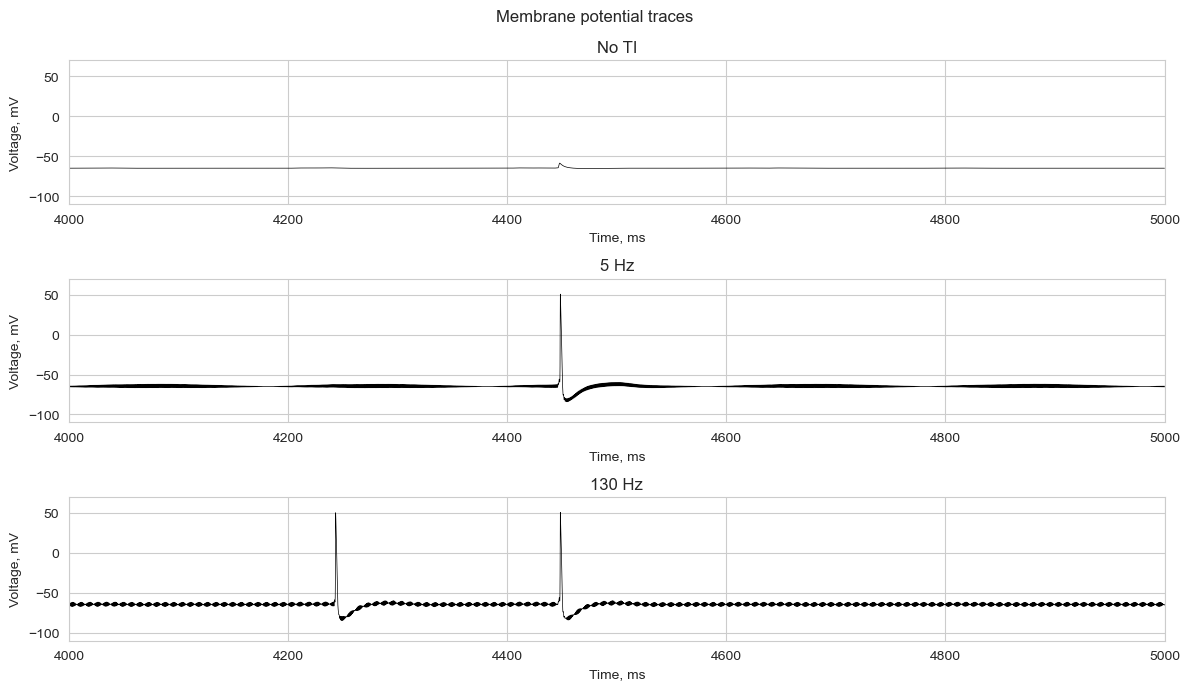

In [211]:
fig, axs = plt.subplots(nrows = 3, ncols = 1, figsize = (12, 7))

for i, label in enumerate(file_labels.keys()):
    voltage = pd.read_csv(f"{output_dir}/{file_labels[label]}/voltage.csv")
    
    axs[i].plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = "black"
    )

    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Voltage, mV")

    axs[i].set_xlim(4000, 5000)
    axs[i].set_ylim(-110, 70)
    
    axs[i].set_title(label)

fig.suptitle("Membrane potential traces")
fig.tight_layout()

plt.show()

## Spiking frequency patterns

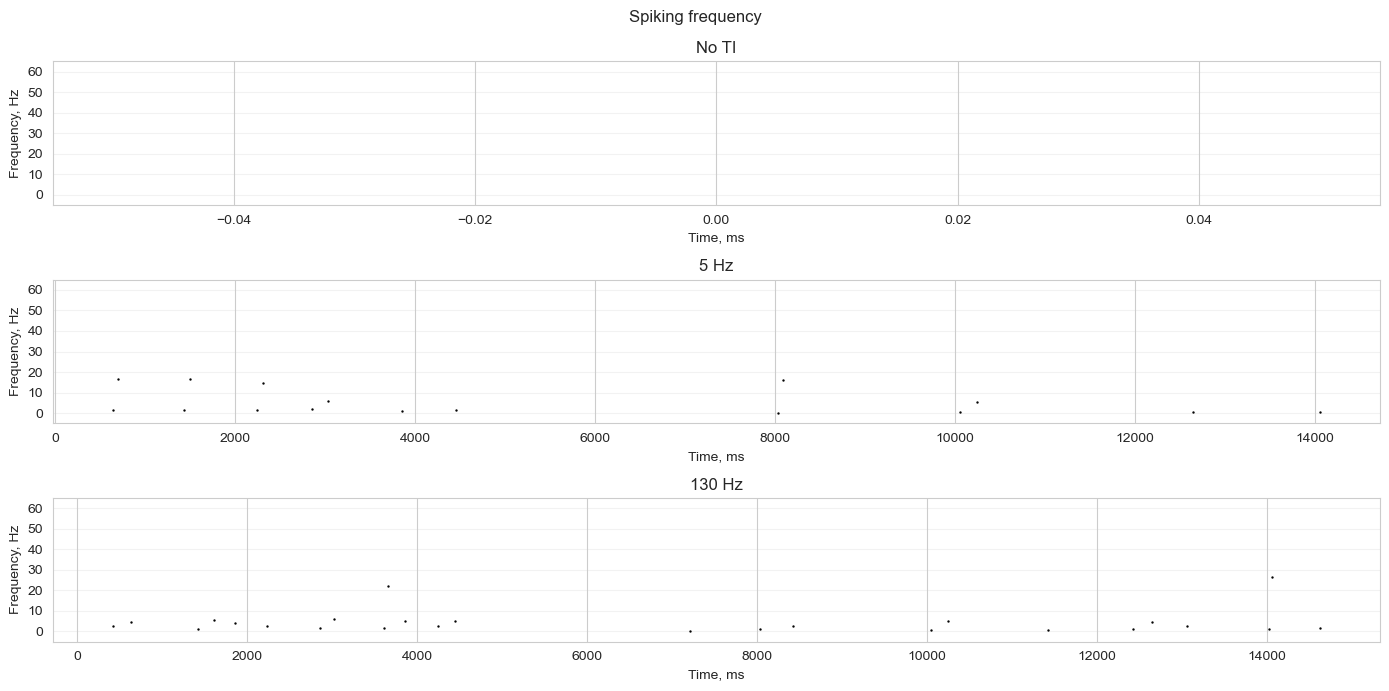

In [212]:
fig, axs = plt.subplots(nrows = 3, ncols = 1, figsize = (14, 7))

for i, label in enumerate(file_labels.keys()):
    spike_frequency = pd.read_csv(f"{output_dir}/{file_labels[label]}/spike_frequency.csv")

    axs[i].scatter(
        spike_frequency.Time,
        spike_frequency.Frequency,
        s = 0.5,
        color = "black",
        zorder = 3
    )

    axs[i].grid(axis = "y", zorder = 0, alpha = 0.25)
    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Frequency, Hz")
    axs[i].set_ylim(-5, 65)
    axs[i].set_yticks(np.arange(0, 65, 10))
    axs[i].set_title(label)

fig.suptitle("Spiking frequency")
fig.tight_layout()

plt.show()

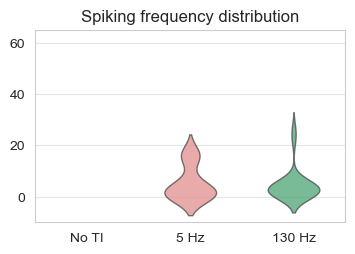

In [213]:
plt.figure(figsize = (4, 2.5))

data = []
for i, label in enumerate(file_labels.keys()):
    spike_frequency = pd.read_csv(f"{output_dir}/{file_labels[label]}/spike_frequency.csv")
    data.append(spike_frequency.Frequency.values)

sns.violinplot(
    data = data,
    width = 0.5,
    palette = colors.values(),
    zorder = 3,
    alpha = 0.75,
    inner = None,
    linewidth = 1
)

plt.xticks([0, 1, 2], colors.keys())
plt.ylim(-10, 65)
plt.title("Spiking frequency distribution")
plt.grid(axis = "y", zorder = 0, alpha = 0.5)

plt.show()

In [214]:
def calculate_spike_times(spike_frequency):
    spike_times = spike_frequency.Time.values
    np.insert(spike_times, 0, spike_frequency.Time[0] - 1000 / spike_frequency.Frequency[0])

    return spike_times

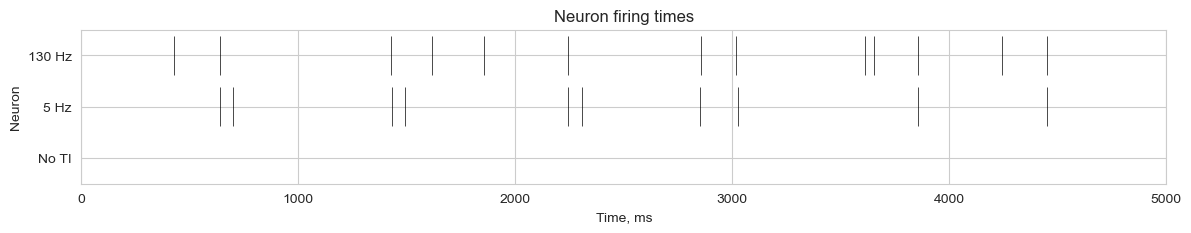

In [215]:
plt.figure(figsize = (14, 2))

for i, label in enumerate(file_labels.keys()):
    spike_frequency = pd.read_csv(f"{output_dir}/{file_labels[label]}/spike_frequency.csv")
    if len(spike_frequency) > 0:
        spike_times = calculate_spike_times(spike_frequency)
        plt.eventplot(spike_times, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

plt.ylim(0.5, 3.5)
plt.ylabel("Neuron")
plt.yticks(np.arange(1, 4, 1), ["No TI", "5 Hz", "130 Hz"])

plt.xlabel("Time, ms")
plt.xlim(0, 5000)

plt.title("Neuron firing times")
plt.show()

/Users/ieva/miniconda3/envs/neuron/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Users/ieva/miniconda3/envs/neuron/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


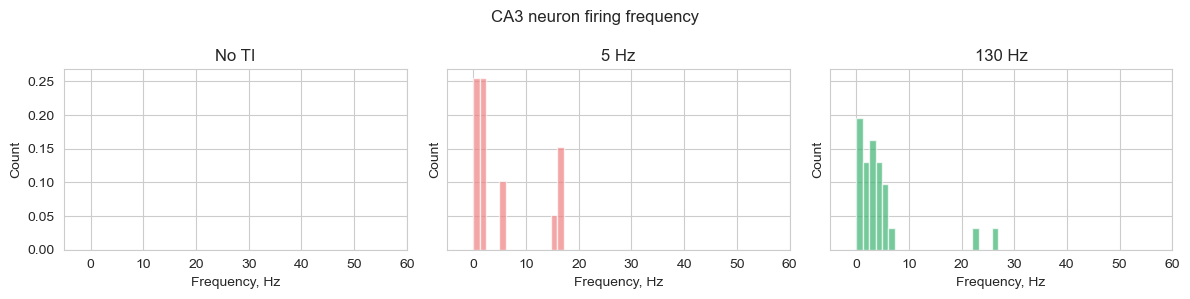

In [216]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3), sharey = True)

min = 0
max = 60

bin_edges = np.linspace(min, max, num = 50)

for i, label in enumerate(file_labels.keys()):
    spike_frequency = pd.read_csv(f"{output_dir}/{file_labels[label]}/spike_frequency.csv").Frequency
    axs[i].hist(spike_frequency, bins = bin_edges, alpha = 0.7, color = colors[label], density = True)
    
    axs[i].set_ylabel("Count")
    axs[i].set_xlabel("Frequency, Hz")
    axs[i].set_xlim(-5, max)
    axs[i].set_title(label)

fig.suptitle("CA3 neuron firing frequency")
fig.tight_layout()
plt.show()

## Interspike intervals (ISI)

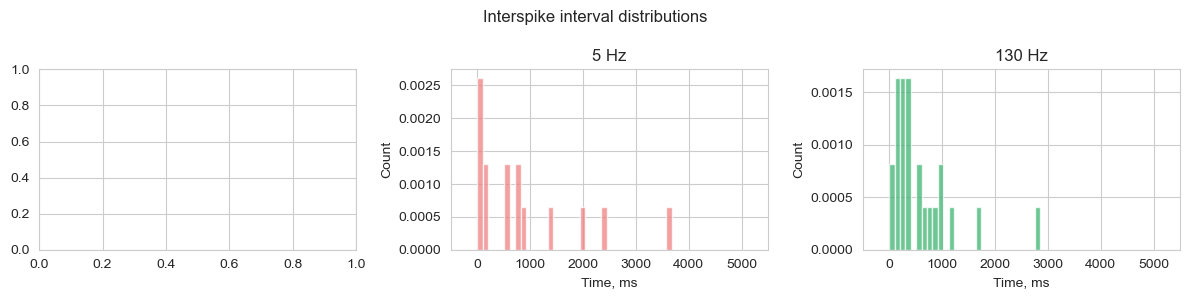

In [217]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3))

min = 0
max = 5000

bin_edges = np.linspace(min, max, num = 50)

for i, label in enumerate(file_labels.keys()):
    spike_frequency = pd.read_csv(f"{output_dir}/{file_labels[label]}/spike_frequency.csv")
    if len(spike_frequency) > 0:
        spike_times = calculate_spike_times(spike_frequency)
        isi = np.diff(spike_times)
        
        loc, scale = stats.expon.fit(isi)
    
        axs[i].hist(isi, bins = bin_edges, density = True, alpha = 0.75, label = label, color = colors[label])
    
        axs[i].set_xlabel("Time, ms")
        axs[i].set_ylabel("Count")
        axs[i].set_title(label)
        axs[i].set_xlim(min - max * 0.1, max * 1.1)

fig.suptitle("Interspike interval distributions")
fig.tight_layout()
plt.show()

## EPSPs

In [218]:
type = "5 Hz"
filetype = file_labels[type]

synapses_voltage = pd.read_csv(f"{output_dir}/{filetype}/synapse_voltage.csv", index_col = 0)
stimuli_times = pd.read_csv(f"{output_dir}/{filetype}/synapse_stimuli.csv", header = None)

In [219]:
synapse_stimuli = np.array(stimuli_times.iloc[0].values)
synapse_stimuli = synapse_stimuli[~np.isnan(synapse_stimuli)]

synapse_voltage = synapses_voltage["Synapse0"].values

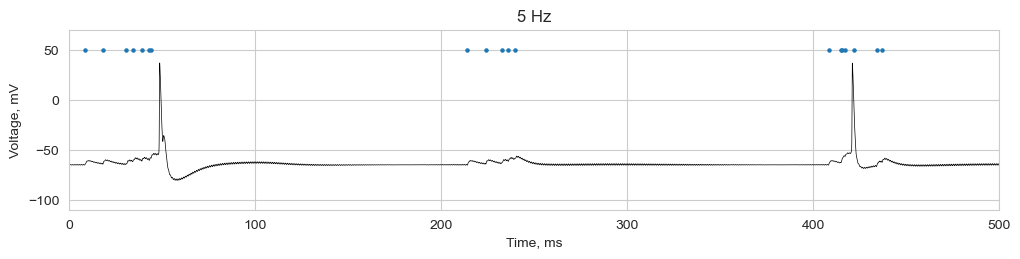

In [220]:
plt.figure(figsize = (12, 7 / 3))

plt.plot(
    synapses_voltage.Time,
    synapse_voltage,
    linewidth = 0.5,
    color = "black"
)

plt.scatter(
    synapse_stimuli,
    np.repeat(50, len(synapse_stimuli)),
    s = 5
)

plt.xlabel("Time, ms")
plt.ylabel("Voltage, mV")

plt.xlim(0, 500)
plt.ylim(-110, 70)

plt.title(type)

fig.suptitle("Membrane potential traces")
fig.tight_layout()

plt.show()

In [221]:
from scipy.signal import butter, filtfilt

In [222]:
def bandpass(data, fs, lowcut=1, highcut=30, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

In [223]:
from scipy.signal import butter, lfilter

def causal_bandpass(data, fs, lowcut=1.0, highcut=30.0, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    b, a = butter(order, [low, high], btype='band')
    return lfilter(b, a, data)

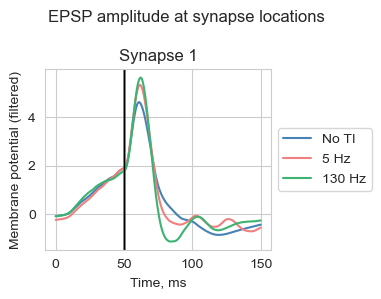

In [224]:
before_length = 50 # ms
epsp_length = 100 # ms

fig, axs = plt.subplots(
    nrows = 1, ncols = 1,
    figsize = (4, 3)
)
# axs = axs.flatten()
axs = [axs]

for i, type in enumerate(file_labels.keys()):
    filetype = file_labels[type]

    synapses_voltage = pd.read_csv(f"{output_dir}/{filetype}/synapse_voltage.csv", index_col = 0)
    stimuli_times = pd.read_csv(f"{output_dir}/{filetype}/synapse_stimuli.csv", header = None)

    for j in range(1):
        synapse_stimuli = np.array(stimuli_times.iloc[j].values)
        synapse_stimuli = synapse_stimuli[~np.isnan(synapse_stimuli)]

        synapse_voltage = synapses_voltage[f"Synapse{j}"].values
        synapse_voltage = causal_bandpass(synapse_voltage, lowcut = 1, highcut = 30, fs = int(1 / (synapses_voltage.Time[1]) * 1000), order = 2)

        volts = []
        time = []
        for stimulus in synapse_stimuli:
            start = stimulus - before_length
            end = stimulus + epsp_length

            if start < 0 or end > synapses_voltage.Time.max():
                continue

            idx = np.where(np.logical_and(synapses_voltage.Time >= start, synapses_voltage.Time <= end))
            time = synapses_voltage.Time.values[idx]
            volt = synapse_voltage[idx]

            volts.append(volt)

        volts = np.vstack(volts)
        time = synapses_voltage[ synapses_voltage.Time < before_length + epsp_length ].Time.values

        axs[j].plot(
            time,
            volts.mean(axis = 0),
            color = colors[type],
            label = type
        )
        axs[j].set_xlabel("Time, ms")
        axs[j].set_ylabel("Membrane potential (filtered)")
        axs[j].set_title(f"Synapse {j + 1}")
        axs[j].axvline(before_length, linewidth = 1, color = "black")

        axs[j].legend(loc = "center left", bbox_to_anchor = (1, 0.5))

fig.suptitle("EPSP amplitude at synapse locations")
fig.tight_layout()
plt.show()